<a href="https://colab.research.google.com/github/sarvesvy/spider_Task_2_submissions/blob/main/task_2_level_1_spml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # First convolutional layer of the block
        self.conv1=nn.Conv2d(in_channels, out_channels, kernel_size=3,stride=stride,
                                            padding=1, bias=False)
        self.bn1=nn.BatchNorm2d(out_channels)

        # Second convolutional layer
        self.conv2=nn.Conv2d(out_channels, out_channels, kernel_size=3,stride=1,
                                          padding=1, bias=False)
        self.bn2=nn.BatchNorm2d(out_channels)

        # Manual Skip Connection
        self.shortcut=nn.Sequential()

        # Handle dimension mismatch: if stride > 1 or channels change,
        # we need a 1x1 conv to match the dimensions for the addition.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out= F.relu(self.bn1(self.conv1(x)))
        out= self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out= F.relu(out)
        return out

In [3]:
class CustomResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomResNet, self).__init__()

        # Base channel size
        self.in_channels = 16

        # Initial Convolution (Output: 32x32x16)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        #here where the resnet starts
        #for each stage it doubles the prev channels 16 ->16 -> 32 C 64
        # and the size reduces by half 32x32 -> 16x16  -> 8*8

        self.stage1 = self._make_stage(out_channels=16, num_blocks=2, stride=1)
        self.stage2 = self._make_stage(out_channels=32, num_blocks=2, stride=2)
        self.stage3 = self._make_stage(out_channels=64, num_blocks=2, stride=2)

        # Global Average Pooling (Output: 1x1x64)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Final Classifier
        self.fc = nn.Linear(64, num_classes)

    def _make_stage(self, out_channels, num_blocks, stride):
        # The first block in the stage might have a stride > 1 to downsample.
        # Subsequent blocks in the same stage always have stride 1.
        strides = [stride] + [1] * (num_blocks - 1)
        blocks = []
        for s in strides:
            blocks.append(ResidualBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels  # Update input channels for the next block

        return nn.Sequential(*blocks)

    def forward(self, x):
        # Initial feature extraction
        out = F.relu(self.bn1(self.conv1(x)))

        # Residual Stages
        out = self.stage1(out)
        out = self.stage2(out)
        out = self.stage3(out)

        # Pooling and Classification
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)  # Flatten all dimensions except batch
        out = self.fc(out)

        return out

In [4]:
#this is for train data
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim

# 1. Prepare CIFAR-10 Dataset with basic augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset=torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True , transform=transform_train)
trainloader=torch.utils.data.DataLoader(
    trainset , batch_size=128 , shuffle=True ,num_workers=2)

# 2. Initialize Model, Loss, and Optimizer
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=CustomResNet(num_classes=10).to(device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

model.train()
for batch_idx, (inputs, targets) in enumerate(trainloader):
    inputs,targets =inputs.to(device),targets.to(device)

    optimizer.zero_grad()
    outputs =model(inputs)
    loss =criterion(outputs, targets)
    loss.backward()
    optimizer.step()

    if batch_idx % 100 == 0:
        print(f"Batch: {batch_idx} | Loss: {loss.item():.4f}")

100%|██████████| 170M/170M [52:01<00:00, 54.6kB/s]


Batch: 0 | Loss: 2.3736
Batch: 100 | Loss: 1.7245
Batch: 200 | Loss: 1.5450
Batch: 300 | Loss: 1.5952


In [5]:
# this is for test data
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=100, shuffle=False, num_workers=2)
classes = testset.classes


epochs = 15
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print("Starting training and validation tracking...")

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device),targets.to(device)

        optimizer.zero_grad()
        outputs=model(inputs)
        loss=criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()
        _, predicted=outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_losses.append(running_loss / len(trainloader))
    train_accs.append(100. * correct / total)

    # --- Validation Phase ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    val_losses.append(val_loss / len(testloader))
    val_accs.append(100. * correct / total)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_accs[-1]:.2f}% | Val Acc: {val_accs[-1]:.2f}%")

Starting training and validation tracking...
Epoch 1/15 | Train Acc: 57.67% | Val Acc: 59.43%
Epoch 2/15 | Train Acc: 66.14% | Val Acc: 61.30%
Epoch 3/15 | Train Acc: 71.35% | Val Acc: 65.56%
Epoch 4/15 | Train Acc: 74.51% | Val Acc: 67.38%
Epoch 5/15 | Train Acc: 75.96% | Val Acc: 73.96%
Epoch 6/15 | Train Acc: 77.35% | Val Acc: 67.14%
Epoch 7/15 | Train Acc: 78.12% | Val Acc: 74.00%
Epoch 8/15 | Train Acc: 78.99% | Val Acc: 72.26%
Epoch 9/15 | Train Acc: 79.53% | Val Acc: 69.64%
Epoch 10/15 | Train Acc: 80.04% | Val Acc: 68.13%
Epoch 11/15 | Train Acc: 80.23% | Val Acc: 77.07%
Epoch 12/15 | Train Acc: 80.59% | Val Acc: 72.09%
Epoch 13/15 | Train Acc: 81.26% | Val Acc: 77.70%
Epoch 14/15 | Train Acc: 81.20% | Val Acc: 79.12%
Epoch 15/15 | Train Acc: 81.12% | Val Acc: 72.00%


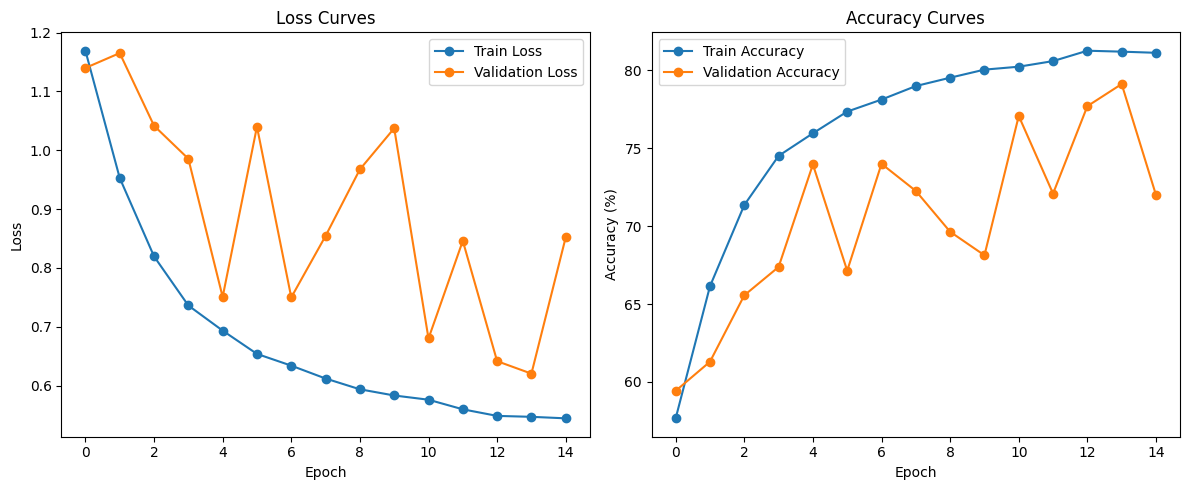

saved as 'training_curves.png'

Model weights saved as 'resnet_cifar10_weights.pth'

FINAL TEST ACCURACY: 72.00% ===

CLASSIFICATION REPORT 
              precision    recall  f1-score   support

    airplane       0.75      0.83      0.79      1000
  automobile       0.97      0.76      0.85      1000
        bird       0.57      0.77      0.66      1000
         cat       0.43      0.68      0.52      1000
        deer       0.88      0.60      0.71      1000
         dog       0.53      0.85      0.66      1000
        frog       0.95      0.46      0.62      1000
       horse       0.92      0.69      0.79      1000
        ship       0.92      0.79      0.85      1000
       truck       0.94      0.78      0.85      1000

    accuracy                           0.72     10000
   macro avg       0.79      0.72      0.73     10000
weighted avg       0.79      0.72      0.73     10000




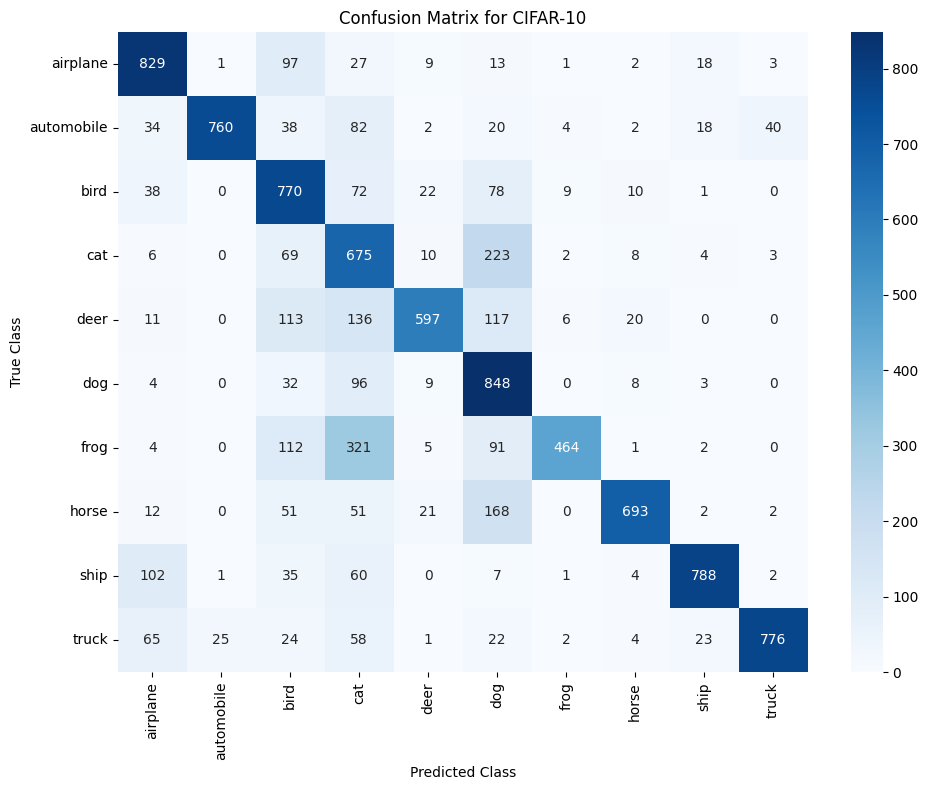

Confusion matrix saved as 'confusion_matrix.png'


In [6]:
# Output 1 & 2: Save Training and Validation Curves
plt.figure(figsize=(12, 5))

# Loss Subplot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Subplot
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy', marker='o')
plt.plot(val_accs, label='Validation Accuracy', marker='o')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()
print("saved as 'training_curves.png'")
print()
# Output 6: Save Model Weights
torch.save(model.state_dict(), 'resnet_cifar10_weights.pth')
print("Model weights saved as 'resnet_cifar10_weights.pth'")
print()
# Gather final predictions for reports
all_preds, all_targets = [],[]
model.eval()
with torch.no_grad():
    for inputs,targets in testloader:
        inputs=inputs.to(device)
        outputs=model(inputs)
        _, predicted=outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.numpy())

# Output 3: Final Accuracy
final_acc = 100 * np.mean(np.array(all_preds) == np.array(all_targets))
print(f"FINAL TEST ACCURACY: {final_acc:.2f}% ===")
print()
# Output 4: Classification Report
print("CLASSIFICATION REPORT ")
print(classification_report(all_targets, all_preds, target_names=classes))
print()
# Output 5: Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix for CIFAR-10')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")